In [1]:
import warnings
# Suppress all warnings
warnings.filterwarnings('ignore')
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

In [2]:
# install scanpy
#%pip install scanpy 


In [3]:
#%pip install scvi-tools

In [4]:
#%pip install harmonypy 

In [5]:
#import sys
#!{sys.executable} -m pip install python-igraph leidenalg



In [6]:
#import sys
#!{sys.executable} -m pip install doubletdetection


In [7]:
import scanpy as sc
import scvi
import harmonypy
import igraph
import leidenalg

print(igraph.__version__)
print("Scanpy:", sc.__version__)
print("scvi-tools:", scvi.__version__)
print(harmonypy.__version__)


0.11.9
Scanpy: 1.11.4
scvi-tools: 1.4.0
0.0.10


## Lung 10x Genomics Data
The datasets used here were collected from 10X Genomics publicly available datasets. 

In [8]:
import anndata as ad

files = [
    "20k_NSCLC_DTC_3p_nextgem_donor_1_count_sample_feature_bc_matrix.h5",
    "20k_NSCLC_DTC_3p_nextgem_donor_5_count_sample_feature_bc_matrix.h5",
    "20k_NSCLC_DTC_3p_nextgem_donor_6_count_sample_feature_bc_matrix.h5",
]

adatas = []
for i, f in enumerate(files, 1):
    Sample_adata = sc.read_10x_h5(f)
    
    # Ensure unique gene names
    Sample_adata.var_names_make_unique()
    
    # Prefix cell barcodes with sample ID to keep them unique globally
    Sample_adata.obs_names = [f"Sample{i}_{bc}" for bc in Sample_adata.obs_names]
    
    # Add sample info
    Sample_adata.obs["Sample"] = f"Sample_{i}"
    
    adatas.append(Sample_adata)

# Concatenate all samples into one AnnData object
adata_all = ad.concat(adatas, join="outer", label="Sample_id", fill_value=0)



In [9]:
# Count cells per sample using the 'Sample' column in obs
cell_counts = adata_all.obs['Sample'].value_counts()
print(cell_counts)


print("Number of cells (obs):", adata_all.n_obs)
print("Number of genes (var):", adata_all.n_vars)

Sample
Sample_3    2921
Sample_2    2378
Sample_1    1580
Name: count, dtype: int64
Number of cells (obs): 6879
Number of genes (var): 36601


In [10]:
import numpy as np
import scanpy as sc

# Helper function to safely get a 1D array
def to_1d(x):
    if hasattr(x, "A1"):  # sparse matrix
        return x.A1
    return np.array(x).ravel()

# Total counts per cell
adata_all.obs['total_counts'] = to_1d(adata_all.X.sum(axis=1))

# Number of genes detected per cell
adata_all.obs['n_genes_by_counts'] = to_1d((adata_all.X > 0).sum(axis=1))

# Mitochondrial gene percentage
mt_genes = adata_all.var_names.str.upper().str.startswith('MT-')
adata_all.obs['pct_counts_mt'] = to_1d(adata_all.X[:, mt_genes].sum(axis=1)) / adata_all.obs['total_counts'] * 100

# Ribosomal gene percentage
ribo_genes = adata_all.var_names.str.upper().str.startswith(('RPS', 'RPL'))
adata_all.obs['pct_counts_ribo'] = to_1d(adata_all.X[:, ribo_genes].sum(axis=1)) / adata_all.obs['total_counts'] * 100

# Check
adata_all.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'Sample']].head()

,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_ribo,Sample
Sample1_AAACCCAGTCTTCGAA-1,5266,29888.0,2.606397,29.025026,Sample_1
Sample1_AAACCCATCACATACG-1,5607,20348.0,0.481620,15.505210,Sample_1
Sample1_AAACGAAAGCCTAACT-1,4147,23584.0,3.180122,12.648405,Sample_1
Sample1_AAACGCTAGACAGTCG-1,1045,3410.0,3.431085,24.017595,Sample_1
Sample1_AAACGCTCAGCAAGAC-1,3470,12665.0,1.097513,34.433479,Sample_1


- **`n_genes_by_counts`** provides a measure of how many genes are actively expressed in a particular cell.
- **`total_counts`** refers to the total number of RNA counts (or read counts) for each cell, representing the overall sequencing depth.
- **`pct_counts_mt`** refers to the percentage of counts in each cell that come from mitochondrial genes.

In [11]:
#Inspect obs (cells metadata)
adata_all.obs.head()

,Sample,Sample_id,total_counts,n_genes_by_counts,pct_counts_mt,pct_counts_ribo
Sample1_AAACCCAGTCTTCGAA-1,Sample_1,0,29888.0,5266,2.606397,29.025026
Sample1_AAACCCATCACATACG-1,Sample_1,0,20348.0,5607,0.481620,15.505210
Sample1_AAACGAAAGCCTAACT-1,Sample_1,0,23584.0,4147,3.180122,12.648405
Sample1_AAACGCTAGACAGTCG-1,Sample_1,0,3410.0,1045,3.431085,24.017595
Sample1_AAACGCTCAGCAAGAC-1,Sample_1,0,12665.0,3470,1.097513,34.433479


# Preprocessing
## Quality Control
However, since some unusual QC metrics may reflect genuine biological variation, it is recommended to start with very lenient filtering and refine it later.  

For now, we only remove cells with fewer than **100 genes detected** and genes that appear in fewer than **3 cells**.

In [12]:
# Calculate QC metrics
adata_all.var["mt"] = adata_all.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata_all, qc_vars=["mt"], inplace=True)

# Filter cells and genes
sc.pp.filter_cells(adata_all, min_genes=200)
sc.pp.filter_genes(adata_all, min_cells=3)

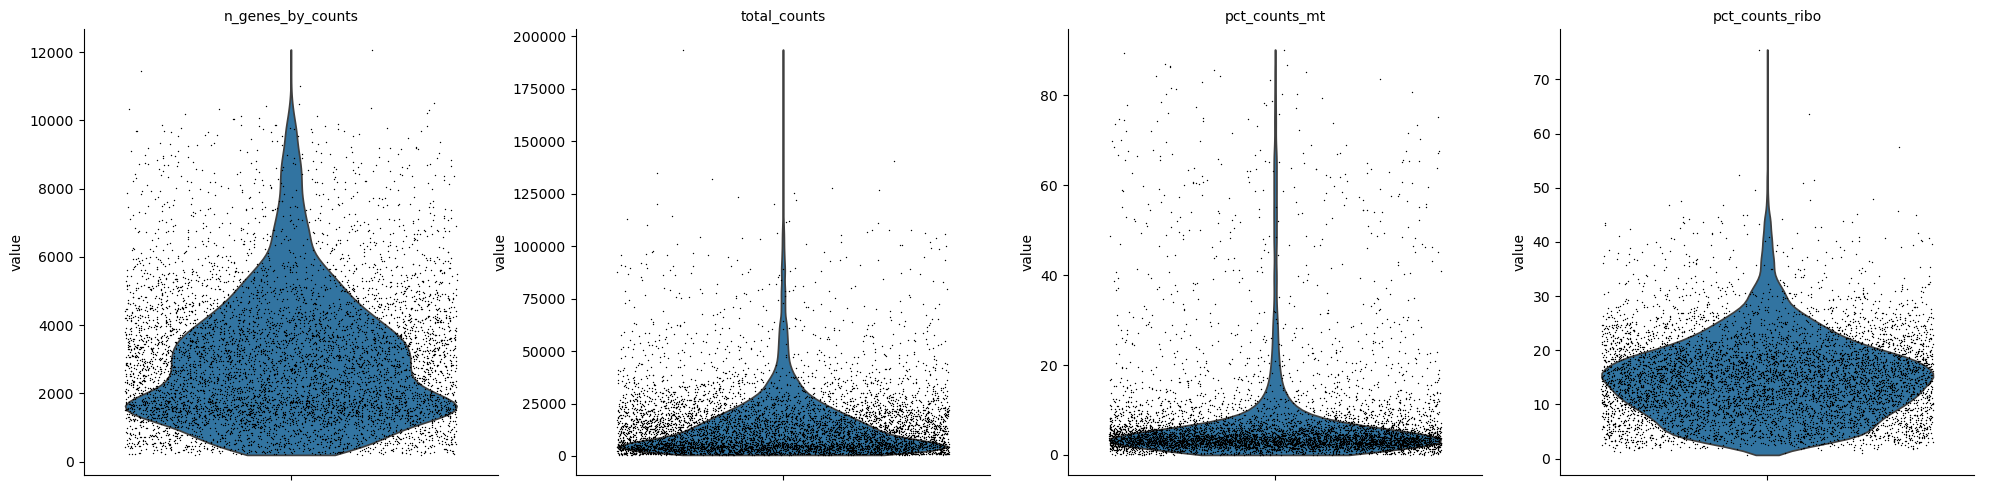

<Figure size 640x480 with 0 Axes>

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

sc.pl.violin(
    adata_all, 
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'], 
    jitter=0.4, 
    multi_panel=True,
    #groupby='donor'  # this will create one violin per donor per metric
)

plt.suptitle('QC metrics across donors', fontsize=16)
plt.show()

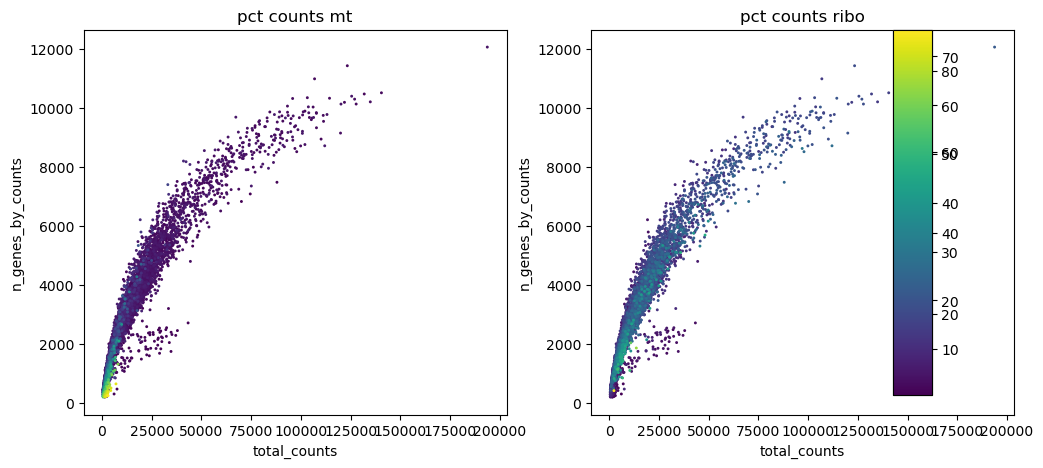

In [14]:
# Create two subplot axes side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# First scatter plot: mitochondrial percentage
sc.pl.scatter(
    adata_all,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt",
    ax=axs[0],
    show=False
)

# Second scatter plot: ribosomal percentage
sc.pl.scatter(
    adata_all,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_ribo",
    ax=axs[1],
    show=True  # Show the combined figure after both plots are done
)

In [15]:
# Check shape
print(adata_all.shape)
print("Number of cells (obs):", adata_all.n_obs)
print("Number of genes (var):", adata_all.n_vars)

(6859, 26674)
Number of cells (obs): 6859
Number of genes (var): 26674


## Normalization and log Transformation

### What `target_sum=1e4` does

`normalize_total` scales each cell’s total counts (UMIs) so that the sum of counts for each cell equals `target_sum`, in this case **10,000**.

Essentially, it **puts all cells on the same scale**, removing differences due to sequencing depth.

After this, every cell is comparable, even if some were sequenced deeper than others.

#### After normalization

All cells have the **same total counts**, so differences now reflect **biological variation**, not sequencing depth.

In [16]:
sc.pp.normalize_total(adata_all, target_sum=1e4)
sc.pp.log1p(adata_all)


## Doublet Detection

In [17]:
import scvi

# Set up AnnData for scVI
scvi.model.SCVI.setup_anndata(adata_all)

# Train scVI
model = scvi.model.SCVI(adata_all)
model.train()  # Use GPU


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


#### Run Solo for Doublet Detection

In [18]:
# Initialize SOLO from your trained scVI model
solo = scvi.external.SOLO.from_scvi_model(model)

# Train SOLO for 350 epochs
solo.train(max_epochs=150) # adjust the epochs

# Predict doublets
predictions = solo.predict()


INFO     Creating doublets, preparing SOLO model.                                                                  


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/150 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=150` reached.


In [19]:
# Add predictions to AnnData obs dataframe
model.adata.obs["solo_doublet_score"] = predictions["doublet"]
model.adata.obs["solo_prediction"] = predictions["singlet"].apply(lambda x: "singlet" if x > 0.5 else "doublet")

# view the results
print(model.adata.obs["solo_prediction"].value_counts())
print(model.adata.obs[["solo_prediction", "solo_doublet_score"]].head())



solo_prediction
singlet    6850
doublet       9
Name: count, dtype: int64
                           solo_prediction  solo_doublet_score
Sample1_AAACCCAGTCTTCGAA-1         singlet            0.000142
Sample1_AAACCCATCACATACG-1         singlet            0.006383
Sample1_AAACGAAAGCCTAACT-1         singlet            0.002935
Sample1_AAACGCTAGACAGTCG-1         singlet            0.007238
Sample1_AAACGCTCAGCAAGAC-1         singlet            0.000165


### Filter out doublets

In [20]:
adata_singlets = model.adata[model.adata.obs["solo_prediction"] == "singlet"].copy()
print(f"Cells after doublet removal: {adata_singlets.n_obs}")

Cells after doublet removal: 6850


In [21]:
threshold = 0.5
adata_filtered = model.adata[model.adata.obs["solo_doublet_score"] < threshold].copy()
print(f"Cells after filtering by score < {threshold}: {adata_filtered.n_obs}")

Cells after filtering by score < 0.5: 6850


In [22]:
adata_filtered

AnnData object with n_obs × n_vars = 6850 × 26674
    obs: 'Sample', 'Sample_id', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'n_genes', '_scvi_batch', '_scvi_labels', 'solo_doublet_score', 'solo_prediction'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', '_scvi_uuid', '_scvi_manager_uuid'

## Feature Selection

In [24]:
sc.pp.highly_variable_genes(
    adata_filtered, 
    flavor="seurat", 
    n_top_genes=2000, 
    batch_key="Sample"
)

adata = adata_filtered[:, adata_filtered.var["highly_variable"]].copy()


## Regress out Confounders
### Linear regression model for each gene expression value across cells

- **`total_counts`**: cells with more sequencing depth will naturally have higher counts.  
- **`pct_counts_mt`**: cells with high mitochondrial gene percentages often reflect stressed or dying cells.  
- **`pct_counts_ribo`**: high ribosomal content may reflect cell cycle state or technical bias.  

---

### Why this is useful

- After regressing out, the data should reflect **true biological variability** rather than technical artifacts.  
- It’s particularly helpful before **PCA or clustering**, where these strong confounders could otherwise dominate the low-dimensional embedding.  
- This doesn’t mean ribosomal or mitochondrial genes are *deleted* — only their effect as a covariate is reduced.  
- If ribosomal or mitochondrial signals are **biologically relevant** for your study (e.g., studying translation or metabolism), you might *not want* to regress them out.  

#### The following function fits a linear regression model for each gene expression value across cells, using the provided covariates (total_counts, pct_counts_mt, pct_counts_ribo) as predictors.

In [25]:
sc.pp.regress_out(adata_filtered, ['total_counts', 'pct_counts_mt', 'pct_counts_ribo'])

## Scaling and PCA

In [26]:
## Scale the data (z-score per gene)
sc.pp.scale(adata_filtered, max_value=10)

## Dimnetionality Reduction
sc.tl.pca(adata_filtered, svd_solver="arpack")


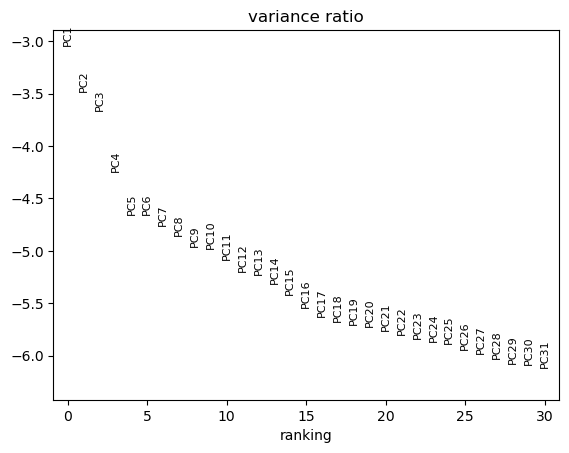

In [27]:
sc.pl.pca_variance_ratio(adata_filtered, log=True)  # elbow plot

## Harmony Integration

In [28]:
import scanpy.external as sce
sce.pp.harmony_integrate(adata_filtered, key="Sample")


2025-09-15 11:38:48,234 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-09-15 11:39:08,494 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-09-15 11:39:08,546 - harmonypy - INFO - Iteration 1 of 10
2025-09-15 11:39:09,645 - harmonypy - INFO - Iteration 2 of 10
2025-09-15 11:39:10,737 - harmonypy - INFO - Iteration 3 of 10
2025-09-15 11:39:11,776 - harmonypy - INFO - Iteration 4 of 10
2025-09-15 11:39:12,947 - harmonypy - INFO - Iteration 5 of 10
2025-09-15 11:39:13,596 - harmonypy - INFO - Iteration 6 of 10
2025-09-15 11:39:14,166 - harmonypy - INFO - Iteration 7 of 10
2025-09-15 11:39:14,761 - harmonypy - INFO - Iteration 8 of 10
2025-09-15 11:39:15,278 - harmonypy - INFO - Iteration 9 of 10
2025-09-15 11:39:15,856 - harmonypy - INFO - Iteration 10 of 10
2025-09-15 11:39:16,492 - harmonypy - INFO - Stopped before convergence


## Neighbors, UMAP, Clustering

In [29]:
## Build neighborhood graph
## For downstream clustering and UMAP.
sc.pp.neighbors(adata_filtered, use_rep="X_pca_harmony", n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_filtered)
sc.tl.leiden(adata_filtered, resolution=0.5)


## Visualization

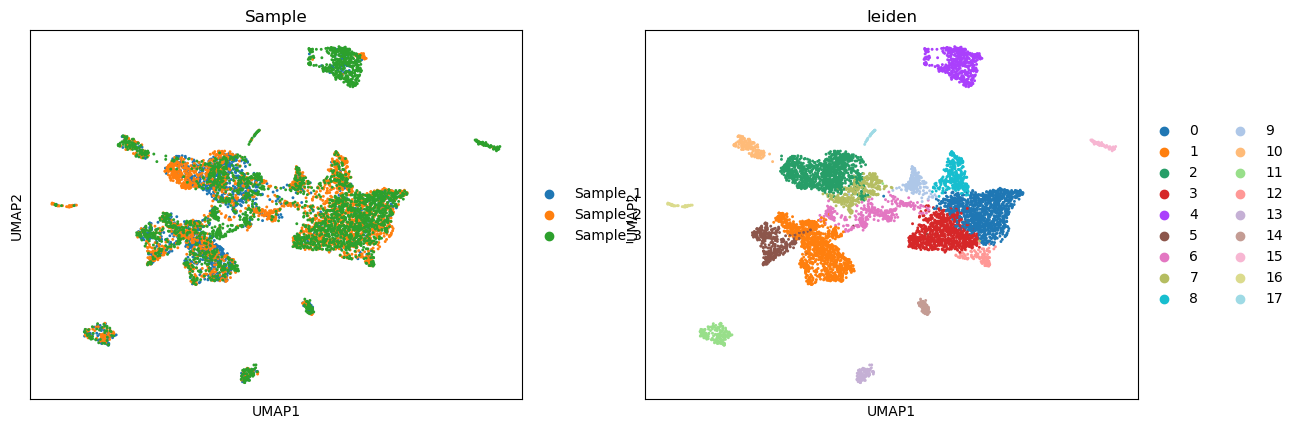

In [30]:
sc.pl.umap(adata_filtered, color=["Sample", "leiden"])


In [31]:
# Save AnnData for further analysis
adata_filtered.write("adata_filtered.h5ad")